# Initialization

In [1]:
import stim
import stim
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states, get_q1prep_accepted_states

import torch
import torch.nn.functional as F

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Notebook to Generate Figures

In [202]:
lstate = "x"
n = 4
i = 7
sim_type = "m1"

meas_type = convert_i_to_meas_type(i, n, lstate)
print(meas_type)

# 1. Load simulation results
# df = pd.read_csv("simulation_results.csv")
# df = pd.read_csv(f"NN_Model/qpc_{lstate}_n{n}_i{i}_{sim_type}.csv")
df = pd.read_csv(f"NN_Model/eval_results/evaluation_results_chunked_{lstate}_n{n}_i{i}_{sim_type}.csv")
# evaluation_results_chunked_z_n4_i7_m1
df

['z', 'x', 'z', 'x']


,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,prep_rate,ler_clean,ler_all
0,4,16,7,x,m1,0.010,0.50,112976,247612,0.456262,0.001598,0.021350
1,4,16,7,x,m1,0.010,0.51,166419,328399,0.506759,0.001541,0.021007
2,4,16,7,x,m1,0.010,0.52,201987,389112,0.519097,0.001500,0.020883
3,4,16,7,x,m1,0.010,0.53,220935,429469,0.514438,0.001505,0.020920
4,4,16,7,x,m1,0.010,0.54,226157,450043,0.502523,0.001503,0.020968
...,...,...,...,...,...,...,...,...,...,...,...,...
270,4,16,7,x,m1,0.001,0.80,460018,499970,0.920091,-0.000001,0.000226
271,4,16,7,x,m1,0.001,0.85,460018,499981,0.920071,-0.000001,0.000226
272,4,16,7,x,m1,0.001,0.90,460018,499994,0.920047,-0.000001,0.000226
273,4,16,7,x,m1,0.001,0.95,460018,499998,0.920040,-0.000001,0.000226


In [203]:
# Define parameter groups
group_cols = ['n', 'N', 'i', 'lstate', 'sim_type', 'p_error', 'prob_threshold']
base_cols = ['n', 'N', 'i', 'lstate', 'sim_type', 'p_error']

# Step 1: Aggregate sums for count_accept and total_data
df_agg = df.groupby(group_cols, as_index=False)[
    ['count_accept', 'total_data', 'ler_clean']
].mean()
# ].sum()

df_agg

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,ler_clean
0,4,16,7,x,m1,0.001,0.05,0.000000,14.0,1.000000
1,4,16,7,x,m1,0.001,0.10,0.000000,20.0,1.000000
2,4,16,7,x,m1,0.001,0.15,0.000000,25.0,1.000000
3,4,16,7,x,m1,0.001,0.20,0.000000,36.0,1.000000
4,4,16,7,x,m1,0.001,0.25,0.000000,47.0,1.000000
...,...,...,...,...,...,...,...,...,...,...
145,4,16,7,x,m1,0.010,0.80,230345.000000,497372.0,0.001452
146,4,16,7,x,m1,0.010,0.85,230345.000000,498102.0,0.001452
147,4,16,7,x,m1,0.010,0.90,230345.000000,498715.0,0.001452
148,4,16,7,x,m1,0.010,0.95,230345.000000,499380.0,0.001452


In [204]:
# Step 2: Extract baseline total_data where prob_threshold == 1.0
baseline = (
    df_agg[df_agg['prob_threshold'] == 1.0]
    .groupby(base_cols)[['count_accept', 'total_data', 'ler_clean']]
    .first()
    .reset_index()
    .rename(columns={
        'count_accept': 'baseline_accept',
        'total_data': 'baseline_total',
        'ler_clean': 'baseline_ler'
    })
)

# Step 3: Broadcast the baseline total_data back to all rows in each group
df_final = df_agg.merge(baseline, on=base_cols, how='left')
# df_final['total_data'] = df_final['baseline_total']
# df_final.drop(columns=['baseline_total'], inplace=True)

# Step 4: Recalculate prep_rate
df_final['prep_rate'] = np.where(
    df_final['total_data'] > 0,
    df_final['count_accept'] / df_final['total_data'],
    0.0,
)

import numpy as np

# Step 1: Compute metrics
df_final["accepted_yield"] = np.where(
    df_final["baseline_accept"] > 0,
    df_final["count_accept"] / df_final["baseline_accept"],
    0.0,
)


df_final

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,ler_clean,baseline_accept,baseline_total,baseline_ler,prep_rate,accepted_yield
0,4,16,7,x,m1,0.001,0.05,0.000000,14.0,1.000000,460240.000000,500000.0,3.617145e-07,0.000000,0.000000
1,4,16,7,x,m1,0.001,0.10,0.000000,20.0,1.000000,460240.000000,500000.0,3.617145e-07,0.000000,0.000000
2,4,16,7,x,m1,0.001,0.15,0.000000,25.0,1.000000,460240.000000,500000.0,3.617145e-07,0.000000,0.000000
3,4,16,7,x,m1,0.001,0.20,0.000000,36.0,1.000000,460240.000000,500000.0,3.617145e-07,0.000000,0.000000
4,4,16,7,x,m1,0.001,0.25,0.000000,47.0,1.000000,460240.000000,500000.0,3.617145e-07,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,4,16,7,x,m1,0.010,0.80,230345.000000,497372.0,0.001452,230108.333333,500000.0,1.426116e-03,0.463124,1.001029
146,4,16,7,x,m1,0.010,0.85,230345.000000,498102.0,0.001452,230108.333333,500000.0,1.426116e-03,0.462445,1.001029
147,4,16,7,x,m1,0.010,0.90,230345.000000,498715.0,0.001452,230108.333333,500000.0,1.426116e-03,0.461877,1.001029
148,4,16,7,x,m1,0.010,0.95,230345.000000,499380.0,0.001452,230108.333333,500000.0,1.426116e-03,0.461262,1.001029


In [205]:

# Step 2: Compute Composite F1-Score
denom = df_final["prep_rate"] + df_final["accepted_yield"]
df_final["f1_score"] = np.where(
    denom > 0,
    2 * (df_final["prep_rate"] * df_final["accepted_yield"]) / denom,
    0.0,
)
df_final["product_score"] = df_final["prep_rate"] * df_final["accepted_yield"]

# Step 3: Find Optimal T for each p_error group
optimal_per_group = df_final.loc[
    df_final.groupby(base_cols)["f1_score"].idxmax()
]

optimal_per_group[["p_error", "prob_threshold", "prep_rate", "ler_clean", "accepted_yield", "f1_score", "product_score"]]

,p_error,prob_threshold,prep_rate,ler_clean,accepted_yield,f1_score,product_score
17,0.0010,0.56,0.924689,0.000001,1.000048,0.960893,0.924733
46,0.0025,0.55,0.827683,0.000021,0.996258,0.904180,0.824585
76,0.0050,0.55,0.691252,0.000179,0.996304,0.816206,0.688697
103,0.0075,0.53,0.600717,0.000594,0.957233,0.738183,0.575026
133,0.0100,0.53,0.513593,0.001456,0.958256,0.668756,0.492154


In [206]:
baseline["prep_rate"] = baseline["baseline_accept"] / baseline["baseline_total"]
baseline

,n,N,i,lstate,sim_type,p_error,baseline_accept,baseline_total,baseline_ler,prep_rate
0,4,16,7,x,m1,0.0010,460240.000000,500000.0,3.617145e-07,0.920480
1,4,16,7,x,m1,0.0025,407071.333333,500000.0,2.497127e-05,0.814143
2,4,16,7,x,m1,0.0050,333742.000000,500000.0,1.972576e-04,0.667484
3,4,16,7,x,m1,0.0075,276266.666667,500000.0,5.694983e-04,0.552533
4,4,16,7,x,m1,0.0100,230108.333333,500000.0,1.426116e-03,0.460217


In [207]:
best_group = optimal_per_group.reset_index(drop=True)
(best_group["prep_rate"] - baseline["prep_rate"]) / baseline["prep_rate"]

0    0.004572
1    0.016631
2    0.035608
3    0.087205
4    0.115981
Name: prep_rate, dtype: float64

In [208]:
# Compute direct product score
df_final["product_score"] = df_final["prep_rate"] * df_final["accepted_yield"]

# Extract optimal T per p_error
optimal_product = df_final.loc[
    df_final.groupby(base_cols)["product_score"].idxmax()
]
optimal_product

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,total_data,ler_clean,baseline_accept,baseline_total,baseline_ler,prep_rate,accepted_yield,f1_score,product_score
17,4,16,7,x,m1,0.0010,0.56,460262.000000,497748.000000,0.000001,460240.000000,500000.0,3.617145e-07,0.924689,1.000048,0.960893,0.924733
46,4,16,7,x,m1,0.0025,0.55,405548.000000,489980.000000,0.000021,407071.333333,500000.0,2.497127e-05,0.827683,0.996258,0.904180,0.824585
76,4,16,7,x,m1,0.0050,0.55,332508.333333,481023.333333,0.000179,333742.000000,500000.0,1.972576e-04,0.691252,0.996304,0.816206,0.688697
105,4,16,7,x,m1,0.0075,0.55,275411.000000,472510.000000,0.000559,276266.666667,500000.0,5.694983e-04,0.582868,0.996903,0.735629,0.581063
135,4,16,7,x,m1,0.0100,0.55,229423.000000,463864.000000,0.001462,230108.333333,500000.0,1.426116e-03,0.494591,0.997022,0.661188,0.493118


In [209]:
# Average the scores across all p_error for each threshold
mean_scores = (
    df_final.groupby("prob_threshold")["f1_score"]
    .mean()
    .reset_index()
)

# Identify global optimal threshold T*
optimal_global_T = mean_scores.loc[mean_scores["f1_score"].idxmax(), "prob_threshold"]
print(f"Global Optimal Threshold T* = {optimal_global_T}")

Global Optimal Threshold T* = 0.5499999999999999


## First Table (LER)

In [210]:
best_group[["n", "N","i","lstate","sim_type","p_error", "prob_threshold", "count_accept","ler_clean","baseline_ler"]]

,n,N,i,lstate,sim_type,p_error,prob_threshold,count_accept,ler_clean,baseline_ler
0,4,16,7,x,m1,0.0010,0.56,460262.000000,0.000001,3.617145e-07
1,4,16,7,x,m1,0.0025,0.55,405548.000000,0.000021,2.497127e-05
2,4,16,7,x,m1,0.0050,0.55,332508.333333,0.000179,1.972576e-04
3,4,16,7,x,m1,0.0075,0.53,264451.666667,0.000594,5.694983e-04
4,4,16,7,x,m1,0.0100,0.53,220502.666667,0.001456,1.426116e-03


In [ ]:
# n	N	i	lstate	sim_type	p_error	prob_threshold	count_accept	ler_clean	baseline_ler
# 4	4	16	6	z	m1	0.0100	0.53	223460.666667	5.615239e-04	0.000514 +12%
# 4	4	16	6	x	m1	0.0100	0.70	145203.0	0.000427	4.784228e-04 +3%
# 4	4	16	7	x	m1	0.0100	0.53	220502.666667	0.001456	1.426116e-03 +12%
# 4	4	16	7	z	m1	0.0100	0.58	170986.333333	0.000306	2.810270e-04 +17%
# 4	5	32	25	z	m1	0.0100	0.85	22774.4	3.423200e-04	3.227083e-04 +1%
# 4	5	32	25	x	m1	0.0100	0.52	243723.8	5.719582e-04	5.696774e-04 +12%





## First Figure

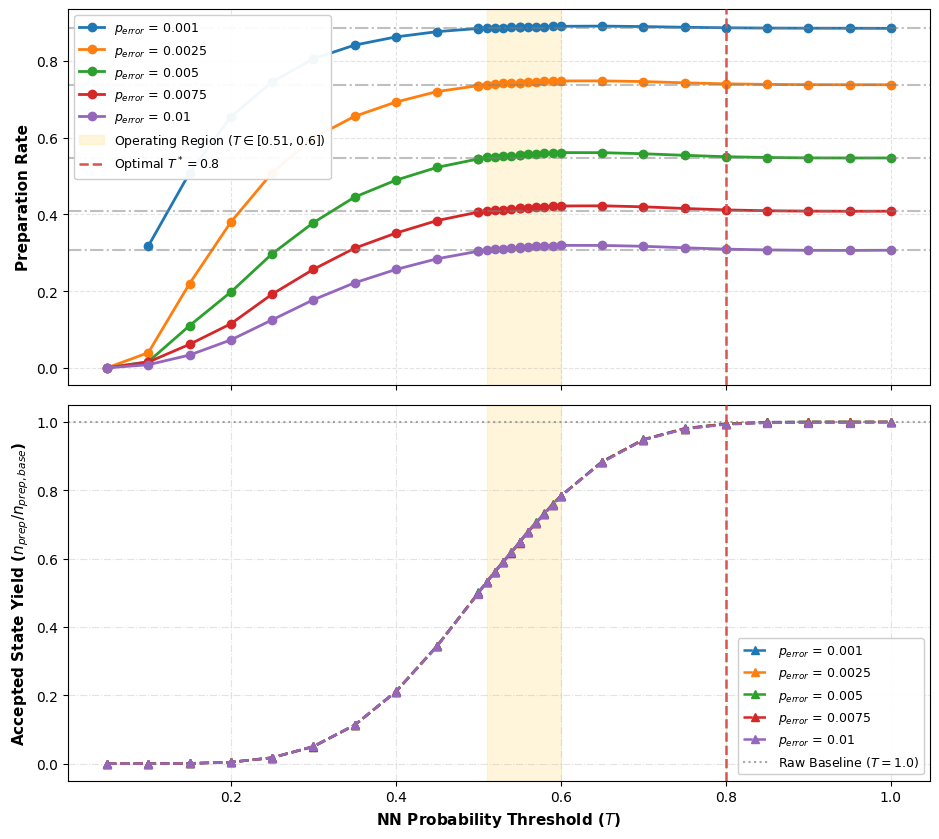

In [108]:
import matplotlib.pyplot as plt
import copy

df = copy.deepcopy(df_final)

min_t = 0.51
max_t = 0.6

# ---------------------------------------------------------
# 1. METRICS & DATA SETUP
# ---------------------------------------------------------
# Accepted State Yield (True Positive Retention Rate)
df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]

# Preparation Rate (Fidelity)
df["prep_rate"] = df["count_accept"] / df["total_data"]

n_val = df["n"].iloc[0] if "n" in df.columns else 4
lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
i_val = df["i"].iloc[0] if "i" in df.columns else 7

optimal_T = np.round(optimal_global_T, 2)  # Sweet spot threshold

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 8.5), sharex=True)

# ---------------------------------------------------------
# PANEL 1: PREPARATION RATE VS THRESHOLD
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    ax1.plot(
        group["prob_threshold"],
        group["prep_rate"],
        marker="o",
        linewidth=2,
        label=f"$p_{{error}}$ = {p_err}",
    )

    # Optional: Draw raw baseline prep rate per p_error
    raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
    ax1.axhline(
        y=raw_prep_rate,
        linestyle="-.",
        alpha=0.5,
        color="gray"
    )

# Highlight Zone T = 0.5 to 0.6
ax1.axvspan(
    min_t,
    max_t,
    color="#ffe599",
    alpha=0.35,
    zorder=0,
    label=f"Operating Region ($T \\in [{min_t}, {max_t}]$)",
)

# Vertical Line at Optimal T
ax1.axvline(
    x=optimal_T,
    color="#d9534f",
    linestyle="--",
    linewidth=1.8,
    zorder=4,
    label=f"Optimal $T^* = {optimal_T}$",
)

ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | QED NN Filter Performance",
#     fontsize=13,
#     fontweight="bold",
#     pad=12,
# )
ax1.grid(True, linestyle="--", alpha=0.35)
ax1.legend(fontsize=9, loc="upper left", framealpha=0.95)

# ---------------------------------------------------------
# PANEL 2: ACCEPTED STATE YIELD VS THRESHOLD
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    ax2.plot(
        group["prob_threshold"],
        group["accepted_yield"],
        marker="^",
        linestyle="--",
        linewidth=1.8,
        label=f"$p_{{error}}$ = {p_err}",
    )

# Highlight Zone T = 0.5 to 0.6
ax2.axvspan(min_t, max_t, color="#ffe599", alpha=0.35, zorder=0)

# Vertical Line at Optimal T
ax2.axvline(x=optimal_T, color="#d9534f", linestyle="--", linewidth=1.8, zorder=4)

# Raw Baseline Reference (100% accepted states)
ax2.axhline(
    y=1.0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    label="Raw Baseline ($T=1.0$)",
)

# # Text Annotation inside Panel 2
# ax2.text(
#     # x=optimal_T + 0.01,
#     x=optimal_T - 0.32,
#     y=0.45,
#     s=f"Peak Harmonic Score\n(~98% Yield preserved at T={optimal_T})",
#     color="#b52b27",
#     fontsize=9.5,
#     fontweight="bold",
#     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#d9534f", alpha=0.9),
# )

ax2.set_xlabel("NN Probability Threshold ($T$)", fontsize=11, fontweight="bold")
ax2.set_ylabel(
    "Accepted State Yield ($n_{prep} / n_{prep, base}$)",
    fontsize=11,
    fontweight="bold",
)
ax2.grid(True, linestyle="-.", alpha=0.35)
ax2.legend(fontsize=9, loc="lower right", framealpha=0.95)

plt.tight_layout()
plt.savefig(f"qed_filter_highlighted_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
plt.show()

## Second Figure

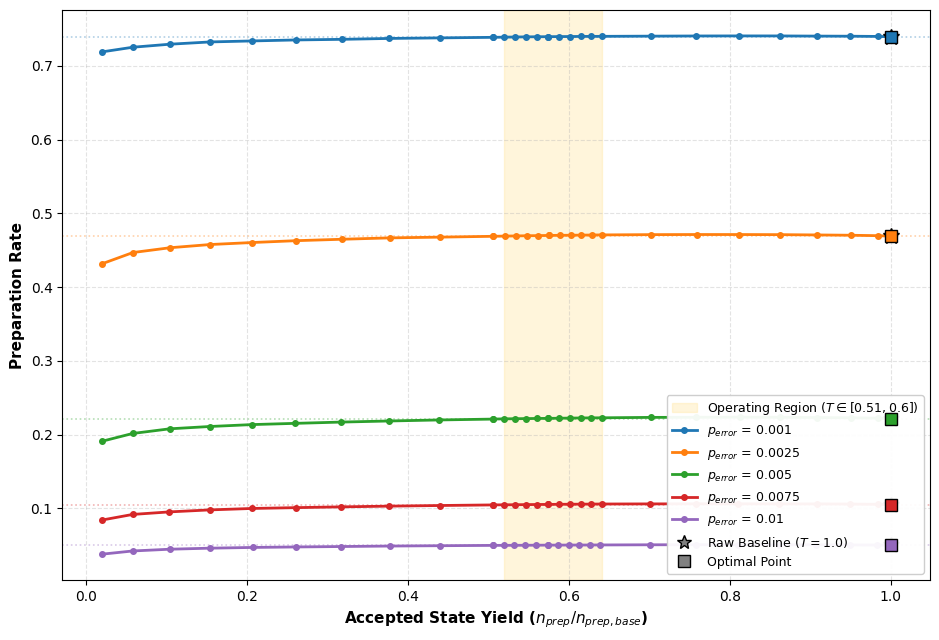

In [9]:
import matplotlib.pyplot as plt

# 1. Recalculate metrics
df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]
df["prep_rate"] = df["count_accept"] / df["total_data"]

n_val = df["n"].iloc[0] if "n" in df.columns else 4
lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
i_val = df["i"].iloc[0] if "i" in df.columns else 7

fig, ax = plt.subplots(figsize=(9.5, 6.5))

# ---------------------------------------------------------
# A. HIGHLIGHT OPERATING ZONE (T in [0.5, 0.6])
# ---------------------------------------------------------
# Find min and max yield (X-axis range) corresponding to T in [0.5, 0.6]
zone_df = df[df["prob_threshold"].between(min_t, max_t)]
x_min = zone_df["accepted_yield"].min()
x_max = zone_df["accepted_yield"].max()

ax.axvspan(
    x_min,
    x_max,
    color="#ffe599",
    alpha=0.35,
    zorder=0,
    label=f"Operating Region ($T \\in [{min_t}, {max_t}]$)",
)

# ---------------------------------------------------------
# B. PLOT CURVES & HIGHLIGHT KEY THRESHOLD POINTS
# ---------------------------------------------------------
for p_err, group in df.groupby("p_error"):
    group = group.sort_values("prob_threshold")

    # Full Pareto Curve
    (line,) = ax.plot(
        group["accepted_yield"],
        group["prep_rate"],
        marker="o",
        markersize=4,
        linewidth=2,
        label=f"$p_{{error}}$ = {p_err}",
        zorder=2,
    )

    # 1. Mark Baseline Point (T = 1.0) with Star
    baseline_row = group[group["prob_threshold"] == 1.0]
    if not baseline_row.empty:
        base_prep = baseline_row["prep_rate"].values[0]
        ax.plot(
            1.0,
            base_prep,
            marker="*",
            markersize=12,
            color=line.get_color(),
            markeredgecolor="black",
            zorder=5,
        )
        ax.axhline(
            y=base_prep,
            color=line.get_color(),
            linestyle=":",
            alpha=0.35,
            linewidth=1.2,
        )

    # 2. Mark Optimal Point (T ≈ 0.57) with Square
    opt_row = group.iloc[(group["prob_threshold"] - optimal_global_T).abs().argsort()[:1]]
    if not opt_row.empty:
        opt_x = opt_row["accepted_yield"].values[0]
        opt_y = opt_row["prep_rate"].values[0]
        ax.plot(
            opt_x,
            opt_y,
            marker="s",
            markersize=8,
            color=line.get_color(),
            markeredgecolor="black",
            zorder=6,
        )

# ---------------------------------------------------------
# C. LEGEND & FORMATTING
# ---------------------------------------------------------
# Custom Legend Entries for Markers
ax.plot(
    [],
    [],
    marker="*",
    markersize=10,
    color="gray",
    markeredgecolor="black",
    linestyle="None",
    label="Raw Baseline ($T=1.0$)",
)
ax.plot(
    [],
    [],
    marker="s",
    markersize=8,
    color="gray",
    markeredgecolor="black",
    linestyle="None",
    label="Optimal Point ",
)

ax.set_xlabel(
    "Accepted State Yield ($n_{prep} / n_{prep, base}$)",
    fontsize=11,
    fontweight="bold",
)
ax.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax.set_title(
#     f"QED Filter Pareto Trade-off (n = {n_val}, State = {lstate_val}, i = {i_val})",
#     fontsize=12,
#     fontweight="bold",
#     pad=12,
# )

ax.grid(True, linestyle="--", alpha=0.35)
ax.legend(
    # title="Hardware Error ($p_{error}$)",
    fontsize=9,
    loc="lower right",
    framealpha=0.95,
)

plt.tight_layout()
plt.savefig(
    f"pareto_highlighted_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300
)
plt.show()

## Third Figure (Speedup)

In [36]:
import glob

def plot_speedup_figure(lstate):
    # ---------------------------------------------------------
    # 1. FIND AND COMBINE ALL CSV FILES
    # ---------------------------------------------------------
    # Set directory path (update if files are in a subfolder, e.g., 'Github/quantum_platform/NN_Model')
    data_dir = "NN_Model/"
    file_pattern = os.path.join(data_dir, "nn_vs_classical_speedup*.csv")
    csv_files = glob.glob(file_pattern)

    if not csv_files:
        raise FileNotFoundError(
            f"No matching CSV files found with pattern: {file_pattern}"
        )

    print(f"Found {len(csv_files)} benchmark files:")
    for f in sorted(csv_files):
        print(f" - {os.path.basename(f)}")

    # Read and combine all files into one DataFrame
    df_list = [pd.read_csv(file) for file in csv_files]
    df_combined = pd.concat(df_list, ignore_index=True)

    df_combined = df_combined[df_combined["lstate"] == lstate].copy()

    # ---------------------------------------------------------
    # 2. AGGREGATE METRICS FOR PLOTTING
    # ---------------------------------------------------------
    # Group by system setup (n, i, device) to get mean per-shot latencies
    summary = (
        df_combined.groupby(["n", "i", "device"], as_index=False)[
            ["classical_us_per_shot", "nn_us_per_shot", "speedup_factor"]
        ]
        .mean()
        .sort_values(["n", "i", "device"])
    )

    # Create system label for X-axis (e.g., "n=4, i=6\n(cuda)")
    summary["system_label"] = (
        "n="
        + summary["n"].astype(str)
        + ", i="
        + summary["i"].astype(str)
        + "\n("
        + summary["device"].astype(str).str.upper()
        + ")"
    )

    # ---------------------------------------------------------
    # 3. PLOT BENCHMARK COMPARISON (2 PANELS)
    # ---------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    x = np.arange(len(summary))
    width = 0.35

    # PANEL 1: Latency per Shot (Log Scale)
    bars_class = ax1.bar(
        x - width / 2,
        summary["classical_us_per_shot"],
        width,
        label="Classical CPU",
        color="#d9534f",
        edgecolor="black",
        linewidth=0.8,
    )
    bars_nn = ax1.bar(
        x + width / 2,
        summary["nn_us_per_shot"],
        width,
        label="NN Inference",
        color="#0275d8",
        edgecolor="black",
        linewidth=0.8,
    )

    ax1.set_yscale("log")
    ax1.set_ylabel(
        "Time per Shot ($\\mu$s)", fontsize=11, fontweight="bold"
    )
    # ax1.set_title(
    #     "Combined QED Filter Acceleration Benchmark Across Systems & Hardware",
    #     fontsize=13,
    #     fontweight="bold",
    #     pad=12,
    # )
    ax1.grid(True, which="both", linestyle="--", alpha=0.35)
    ax1.legend(fontsize=10, loc="lower right", framealpha=0.95)

    # Value Labels for Panel 1
    for bar in bars_class:
        h = bar.get_height()
        ax1.annotate(
            f"{h:.1f} $\\mu$s",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 1),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

    for bar in bars_nn:
        h = bar.get_height()
        ax1.annotate(
            f"{h:.2f} $\\mu$s",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 1),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#0275d8",
        )

    # PANEL 2: Speedup Factor
    bars_speedup = ax2.bar(
        x,
        summary["speedup_factor"],
        width * 1.1,
        color="#5cb85c",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
    )

    ax2.set_ylabel("Speedup Factor", fontsize=11, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(summary["system_label"], fontsize=9.5, fontweight="bold")
    ax2.grid(True, linestyle="--", alpha=0.35)
    ax2.set_ylim(0, summary["speedup_factor"].max() * 1.25)

    # Value Labels for Panel 2
    for bar in bars_speedup:
        h = bar.get_height()
        ax2.annotate(
            f"{h:.0f}$\\times$ Speedup",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#1b5e20",
        )

    plt.tight_layout()
    plt.savefig(f"combined_speedup_benchmark_{lstate}.png", dpi=350)
    plt.show()

Found 6 benchmark files:
 - nn_vs_classical_speedup4_6_cpu_ep300.csv
 - nn_vs_classical_speedup4_6_cuda_ep300.csv
 - nn_vs_classical_speedup4_7_cpu_ep300.csv
 - nn_vs_classical_speedup4_7_cuda_ep300.csv
 - nn_vs_classical_speedup5_25_cpu_ep500.csv
 - nn_vs_classical_speedup5_25_cuda_ep500.csv


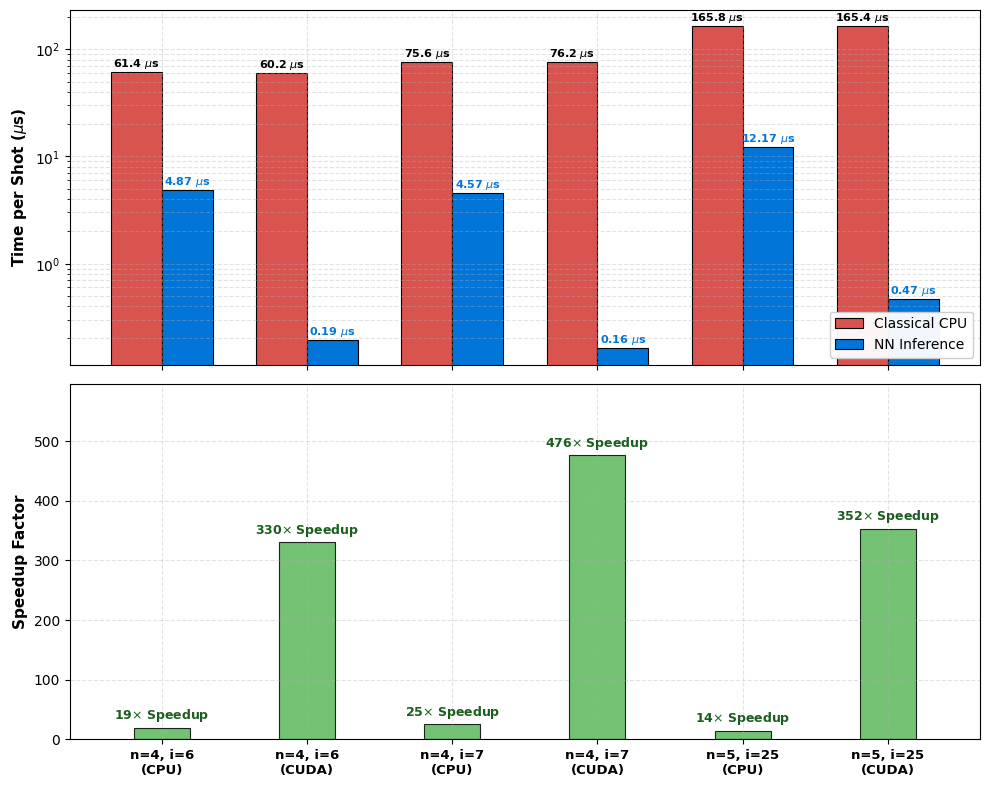

In [37]:
plot_speedup_figure("x")

Found 6 benchmark files:
 - nn_vs_classical_speedup4_6_cpu_ep300.csv
 - nn_vs_classical_speedup4_6_cuda_ep300.csv
 - nn_vs_classical_speedup4_7_cpu_ep300.csv
 - nn_vs_classical_speedup4_7_cuda_ep300.csv
 - nn_vs_classical_speedup5_25_cpu_ep500.csv
 - nn_vs_classical_speedup5_25_cuda_ep500.csv


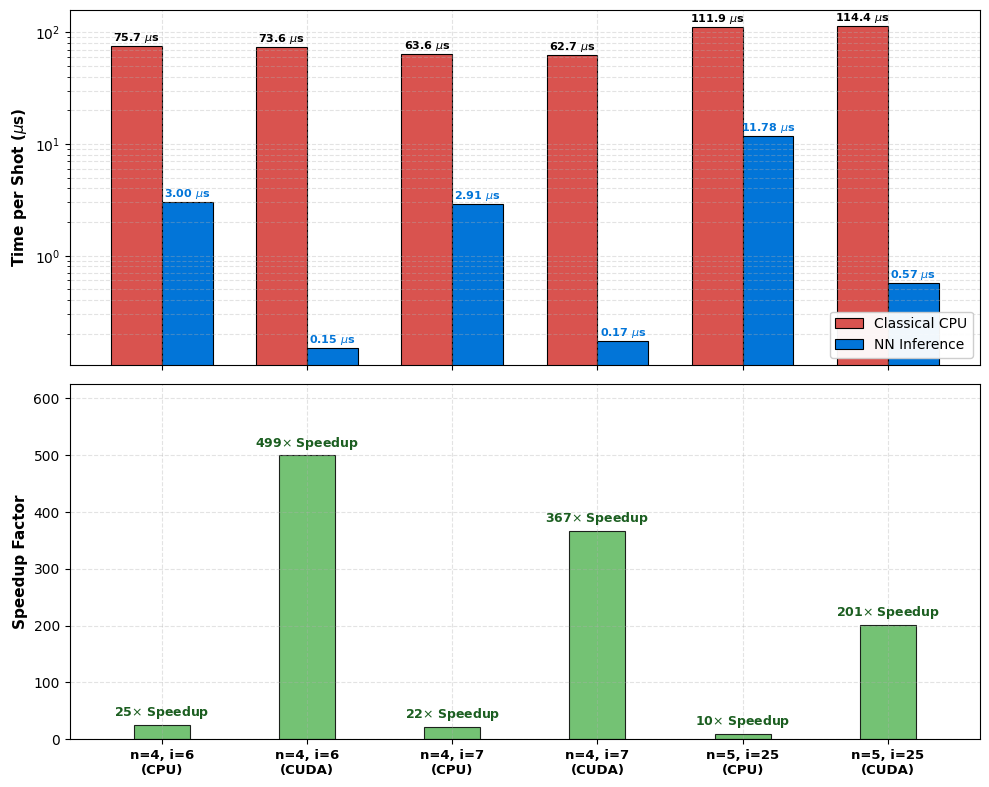

In [38]:
plot_speedup_figure("z")

# Back Up Code

In [ ]:
# def plot_figure(df, N_base):

#     # Normalize values so 1M shots = scale 1.0
#     df["scale_nn"] = df["total_data"] / N_base
#     df["scale_verified"] = df["count_accept"] / df["total_data"]
#     baseline_scale = baseline_count / N_base

#     fig, ax = plt.subplots(figsize=(9, 5.5))

#     # ---------------------------------------------------------
#     # A. BACKGROUND BASELINE (Faded, no legend, with text)
#     # ---------------------------------------------------------
#     ax.axhline(
#         y=baseline_scale,
#         color="gray",
#         linestyle="--",
#         linewidth=1.8,
#         alpha=0.45,  # Faded background look
#         zorder=1,
#     )
#     ax.text(
#         x=0.605,
#         y=baseline_scale * 1,
#         s=f"Normal Approach Baseline ({baseline_scale:.2%})",
#         color="#4a4a4a",
#         fontsize=9.5,
#         fontweight="bold",
#         alpha=0.8,
#         va="bottom",
#     )


#     # ---------------------------------------------------------
#     # C. SIMULATION DATA LINES
#     # ---------------------------------------------------------
#     # NN Filtered compared to 1M Base
#     ax.plot(
#         df["error_prob"],
#         df["scale_nn"],
#         marker="^",
#         color="#ff7f0e",
#         linewidth=2,
#         label="NN Filtered Shots",
#         zorder=3,
#     )

#     # Verified Accepted
#     ax.plot(
#         df["error_prob"],
#         df["scale_verified"],
#         marker="o",
#         color="#1f77b4",
#         linewidth=2,
#         label="Preparation Rate",
#         zorder=4,
#     )

#     # ---------------------------------------------------------
#     # D. FORMATTING
#     # ---------------------------------------------------------
#     # ax.set_yscale("log")
#     ax.set_ylim(bottom=df["scale_verified"].min() * 0.7, top=1)  # Cap scale at 1.0

#     ax.set_xlabel("NN Filter Error Prob", fontsize=12, fontweight="bold")
#     ax.set_ylabel(
#         "Normalized Scale (Relative to 1M Shots)", fontsize=12, fontweight="bold"
#     )
#     ax.set_title(
#         f"n = {n}, State = {lstate}, i = {i}, p = 0.005, NN Residual Block (prop-1)",
#         fontsize=13,
#         fontweight="bold",
#         pad=12,
#     )

#     ax.grid(True, which="both", linestyle="--", alpha=0.35)
#     ax.legend(fontsize=10, loc="lower right", framealpha=0.9)

#     plt.tight_layout()
#     plt.savefig(f"normalized_1m_scale_plot_{lstate}_n{n}_i{i}.png", dpi=300)
#     plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import copy

# # ---------------------------------------------------------
# # 1. DYNAMIC METRIC CALCULATIONS
# # ---------------------------------------------------------

# df = copy.deepcopy(df_final)
# df = df[
#     (df["p_error"] != 0.05) &
#     (df["p_error"] != 0.025)
# ].copy()

# # Compute shot survival scale relative to each group's baseline total
# df["scale_nn"] = df["count_accept"] / df["baseline_accept"]

# # Compute preparation rate (count_accept / total_data)
# df["prep_rate"] = df["count_accept"] / df["total_data"]

# # Extract single state info for title formatting
# n_val = df["n"].iloc[0]
# lstate_val = df["lstate"].iloc[0]
# i_val = df["i"].iloc[0]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# # ---------------------------------------------------------
# # PANEL 1: PREPARATION RATE VS THRESHOLD
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax1.plot(
#         group["prob_threshold"],
#         group["prep_rate"],
#         marker="o",
#         linewidth=2,
#         label=f"$p_{{error}}$ = {p_err}",
#     )
    
#     # Optional: Draw raw baseline prep rate per p_error
#     raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
#     ax1.axhline(
#         y=raw_prep_rate,
#         linestyle="-.",
#         alpha=0.5,
#         color="gray"
#     )

# ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | State Fidelity & Efficiency",
#     fontsize=13,
#     fontweight="bold",
#     pad=10,
# )
# ax1.grid(True, linestyle="--", alpha=0.35)
# ax1.legend(fontsize=9, loc="lower right")

# # ---------------------------------------------------------
# # PANEL 2: SHOT RETENTION / DATA SURVIVAL RATE
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax2.plot(
#         group["prob_threshold"],
#         group["scale_nn"],
#         marker="^",
#         linestyle="--",
#         linewidth=1.8,
#         label=f"$p_{{error}}$ = {p_err}",
#     )

# # Baseline line is y = 1.0 (100% of baseline shots retained at threshold baseline)
# ax2.axhline(
#     y=1.0,
#     color="gray",
#     linestyle="-.",
#     linewidth=1.5,
#     alpha=0.7,
#     label="Raw Baseline (100% Shots)",
# )

# ax2.set_xlabel("NN Probability Threshold", fontsize=11, fontweight="bold")
# ax2.set_ylabel(
#     "Shots Retained (Fraction of Baseline)", fontsize=11, fontweight="bold"
# )
# ax2.grid(True, linestyle="--", alpha=0.35)
# ax2.legend(fontsize=9, loc="lower right")

# plt.tight_layout()
# plt.savefig(f"nn_filter_performance_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# plt.show()


In [96]:
# # ---------------------------------------------------------
# # 1. DYNAMIC METRIC CALCULATIONS
# # ---------------------------------------------------------

# df = copy.deepcopy(df_final)
# # Filter for prob_threshold between 0.5 and 0.6 (inclusive)
# df = df[
#     (df["prob_threshold"] >= 0.5) & 
#     (df["prob_threshold"] <= 0.6) &
#     (df["p_error"] != 0.05) &
#     (df["p_error"] != 0.025)
# ].copy()

# # Compute shot survival scale relative to each group's baseline total
# df["scale_nn"] = df["count_accept"] / df["baseline_accept"]

# # Compute preparation rate (count_accept / total_data)
# df["prep_rate"] = df["count_accept"] / df["total_data"]

# # Extract single state info for title formatting
# n_val = df["n"].iloc[0]
# lstate_val = df["lstate"].iloc[0]
# i_val = df["i"].iloc[0]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# # ---------------------------------------------------------
# # PANEL 1: PREPARATION RATE VS THRESHOLD
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax1.plot(
#         group["prob_threshold"],
#         group["prep_rate"],
#         marker="o",
#         linewidth=2,
#         label=f"$p_{{error}}$ = {p_err}",
#     )
    
#     # Optional: Draw raw baseline prep rate per p_error
#     raw_prep_rate = (group["baseline_accept"] / group["baseline_total"]).iloc[0]
#     ax1.axhline(
#         y=raw_prep_rate,
#         linestyle="-.",
#         alpha=0.5,
#         color="gray"
#     )

# ax1.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# ax1.set_title(
#     f"n = {n_val}, State = {lstate_val}, i = {i_val} | State Fidelity & Efficiency",
#     fontsize=13,
#     fontweight="bold",
#     pad=10,
# )
# ax1.grid(True, linestyle="--", alpha=0.35)
# ax1.legend(fontsize=9, loc="lower right")

# # ---------------------------------------------------------
# # PANEL 2: SHOT RETENTION / DATA SURVIVAL RATE
# # ---------------------------------------------------------
# for p_err, group in df.groupby("p_error"):
#     ax2.plot(
#         group["prob_threshold"],
#         group["scale_nn"],
#         marker="^",
#         linestyle="--",
#         linewidth=1.8,
#         label=f"$p_{{error}}$ = {p_err}",
#     )

# # Baseline line is y = 1.0 (100% of baseline shots retained at threshold baseline)
# ax2.axhline(
#     y=1.0,
#     color="gray",
#     linestyle="-.",
#     linewidth=1.5,
#     alpha=0.7,
#     label="Raw Baseline (100% Shots)",
# )

# ax2.set_xlabel("NN Probability Threshold", fontsize=11, fontweight="bold")
# ax2.set_ylabel(
#     "Shots Retained (Fraction of Baseline)", fontsize=11, fontweight="bold"
# )
# ax2.grid(True, linestyle="--", alpha=0.35)
# ax2.legend(fontsize=9, loc="lower right")

# plt.tight_layout()
# plt.savefig(f"nn_filter_performance_zoomed_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# plt.show()

In [97]:
# import matplotlib.pyplot as plt

# # df["accepted_yield"] = df["count_accept"] / df["baseline_accept"]
# # df["prep_rate"] = df["count_accept"] / df["total_data"]

# # n_val = df["n"].iloc[0] if "n" in df.columns else 4
# # lstate_val = df["lstate"].iloc[0] if "lstate" in df.columns else "z"
# # i_val = df["i"].iloc[0] if "i" in df.columns else 7

# # fig, ax = plt.subplots(figsize=(9, 6))

# # for p_err, group in df.groupby("p_error"):
# #     group = group.sort_values("prob_threshold")

# #     # Plot the full trade-off curve
# #     (line,) = ax.plot(
# #         group["accepted_yield"],
# #         group["prep_rate"],
# #         marker="o",
# #         markersize=5,
# #         linewidth=2,
# #         label=f"$p_{{error}}$ = {p_err}",
# #     )

# #     # 1. Mark the RAW BASELINE point (T = 1.0, where Yield = 1.0)
# #     baseline_row = group[group["prob_threshold"] == 1.0]
# #     if not baseline_row.empty:
# #         base_prep = baseline_row["prep_rate"].values[0]

# #         # Draw a star marker at X = 1.0
# #         ax.plot(
# #             1.0,
# #             base_prep,
# #             marker="*",
# #             markersize=12,
# #             color=line.get_color(),
# #             markeredgecolor="black",
# #             zorder=5,
# #         )

# #         # Draw horizontal reference line extending to X = 1.0
# #         ax.axhline(
# #             y=base_prep,
# #             color=line.get_color(),
# #             linestyle=":",
# #             alpha=0.4,
# #             linewidth=1.2,
# #         )

# # # 2. Add a dummy legend entry for the Baseline marker
# # ax.plot(
# #     [],
# #     [],
# #     marker="*",
# #     markersize=10,
# #     color="gray",
# #     markeredgecolor="black",
# #     linestyle="None",
# #     label="Raw Baseline ($T=1.0$)",
# # )



# # # Formatting
# # ax.set_xlabel(
# #     "Accepted State Yield ($N_{accept} / N_{accept, base}$)",
# #     fontsize=11,
# #     fontweight="bold",
# # )
# # ax.set_ylabel("Preparation Rate", fontsize=11, fontweight="bold")
# # ax.set_title(
# #     f"QED Filter Pareto Trade-off (n = {n_val}, State = {lstate_val}, i = {i_val})",
# #     fontsize=12,
# #     fontweight="bold",
# #     pad=12,
# # )

# # ax.grid(True, linestyle="--", alpha=0.35)
# # ax.legend(title="Hardware Error ($p_{error}$)", fontsize=9, loc="lower left")

# # plt.tight_layout()
# # plt.savefig(f"pareto_with_baselines_{lstate_val}_n{n_val}_i{i_val}.png", dpi=300)
# # plt.show()